###

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import os
os.getcwd()

'C:\\Users\\admin.MYLAB1'

In [20]:
import os

os.chdir(r"C:\Users\admin.MYLAB1\Downloads\Capstone_project1\Capstone_project1")

print(os.getcwd())
print(os.listdir())

C:\Users\admin.MYLAB1\Downloads\Capstone_project1\Capstone_project1
['CAPSTONE PROJECT1.docx', 'customers.csv', 'orders.csv', 'products.csv']


In [21]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Products:", products.shape)

Customers: (800, 6)
Orders: (3500, 11)
Products: (200, 6)


In [22]:
customers.head()

,customer_id,age,gender,city,signup_date,membership
0,10001,56,Female,Mumbai,2023-04-28,Silver
1,10002,46,Male,Delhi,2023-10-04,Silver
2,10003,32,Female,Mumbai,2023-08-08,Normal
3,10004,25,Male,Bangalore,2023-01-26,Normal
4,10005,38,Male,Pune,2024-06-04,Normal


In [23]:
orders.head()

,order_id,order_date,customer_id,city,product_id,category,quantity,selling_price,discount,payment_type,delivery_time
0,90001,2024-03-08,10052,Pune,5084,Fashion,2,155.91,0,COD,30
1,90002,2024-08-23,10354,Hyderabad,5061,Electronics,4,604.04,0,COD,40
2,90003,2024-03-15,10448,Chennai,5096,Electronics,2,733.54,0,Card,99
3,90004,2024-03-01,10395,Bangalore,5041,Electronics,1,178.91,0,Card,94
4,90005,2024-09-05,10403,Pune,5151,Fashion,2,535.06,5,COD,79


In [24]:
products.head()

,product_id,product_name,cost_price,brand,rating,supplier
0,5001,Product_0,544,BrandA,4.1,Local
1,5002,Product_1,279,BrandC,4.3,Local
2,5003,Product_2,69,BrandA,2.5,Local
3,5004,Product_3,602,BrandD,3.0,Imported
4,5005,Product_4,197,BrandB,4.2,Local


In [25]:
print("CUSTOMERS COLUMNS")
print(customers.columns.tolist())

print("\nORDERS COLUMNS")
print(orders.columns.tolist())

print("\nPRODUCTS COLUMNS")
print(products.columns.tolist())

CUSTOMERS COLUMNS
['customer_id', 'age', 'gender', 'city', 'signup_date', 'membership']

ORDERS COLUMNS
['order_id', 'order_date', 'customer_id', 'city', 'product_id', 'category', 'quantity', 'selling_price', 'discount', 'payment_type', 'delivery_time']

PRODUCTS COLUMNS
['product_id', 'product_name', 'cost_price', 'brand', 'rating', 'supplier']


## 3. Data Quality Assessment 

In [27]:
# Check data types and non-null values

print("CUSTOMERS")
customers.info()

print("\nORDERS")
orders.info()

print("\nPRODUCTS")
products.info()

CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  800 non-null    int64 
 1   age          800 non-null    int64 
 2   gender       800 non-null    object
 3   city         800 non-null    object
 4   signup_date  800 non-null    object
 5   membership   800 non-null    object
dtypes: int64(2), object(4)
memory usage: 37.6+ KB

ORDERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       3500 non-null   int64  
 1   order_date     3500 non-null   object 
 2   customer_id    3500 non-null   int64  
 3   city           3500 non-null   object 
 4   product_id     3500 non-null   int64  
 5   category       3500 non-null   object 
 6   quantity       3500 non-null   int6

In [28]:
print("CUSTOMERS")
print(customers.isnull().sum())

print("\nORDERS")
print(orders.isnull().sum())

print("\nPRODUCTS")
print(products.isnull().sum())

CUSTOMERS
customer_id    0
age            0
gender         0
city           0
signup_date    0
membership     0
dtype: int64

ORDERS
order_id         0
order_date       0
customer_id      0
city             0
product_id       0
category         0
quantity         0
selling_price    0
discount         0
payment_type     0
delivery_time    0
dtype: int64

PRODUCTS
product_id      0
product_name    0
cost_price      0
brand           0
rating          0
supplier        0
dtype: int64


In [30]:
print("Customer duplicate rows:", customers.duplicated().sum())
print("Order duplicate rows:", orders.duplicated().sum())
print("Product duplicate rows:", products.duplicated().sum())

Customer duplicate rows: 0
Order duplicate rows: 0
Product duplicate rows: 0


In [31]:
print("Duplicate customer IDs:",
      customers["customer_id"].duplicated().sum())

print("Duplicate order IDs:",
      orders["order_id"].duplicated().sum())

print("Duplicate product IDs:",
      products["product_id"].duplicated().sum())

Duplicate customer IDs: 0
Duplicate order IDs: 0
Duplicate product IDs: 0


In [32]:
invalid_customers = ~orders["customer_id"].isin(
    customers["customer_id"]
)

print("Orders with invalid customer IDs:",
      invalid_customers.sum())

Orders with invalid customer IDs: 0


In [33]:
invalid_products = ~orders["product_id"].isin(
    products["product_id"]
)

print("Orders with invalid product IDs:",
      invalid_products.sum())

Orders with invalid product IDs: 0


In [34]:
print("AGE")
print("Minimum:", customers["age"].min())
print("Maximum:", customers["age"].max())

print("\nQUANTITY")
print("Minimum:", orders["quantity"].min())
print("Maximum:", orders["quantity"].max())

print("\nSELLING PRICE")
print("Minimum:", orders["selling_price"].min())
print("Maximum:", orders["selling_price"].max())

print("\nDISCOUNT")
print("Minimum:", orders["discount"].min())
print("Maximum:", orders["discount"].max())

print("\nDELIVERY TIME")
print("Minimum:", orders["delivery_time"].min())
print("Maximum:", orders["delivery_time"].max())

print("\nRATING")
print("Minimum:", products["rating"].min())
print("Maximum:", products["rating"].max())

print("\nCOST PRICE")
print("Minimum:", products["cost_price"].min())
print("Maximum:", products["cost_price"].max())

AGE
Minimum: 18
Maximum: 59

QUANTITY
Minimum: 1
Maximum: 4

SELLING PRICE
Minimum: 57.45
Maximum: 1116.51

DISCOUNT
Minimum: 0
Maximum: 20

DELIVERY TIME
Minimum: 20
Maximum: 119

RATING
Minimum: 2.5
Maximum: 5.0

COST PRICE
Minimum: 52
Maximum: 699


In [35]:
print("Gender:", customers["gender"].unique())
print("City:", customers["city"].unique())
print("Membership:", customers["membership"].unique())

print("\nCategories:", orders["category"].unique())
print("Payment types:", orders["payment_type"].unique())

print("\nBrands:", products["brand"].unique())
print("Suppliers:", products["supplier"].unique())

Gender: ['Female' 'Male']
City: ['Mumbai' 'Delhi' 'Bangalore' 'Pune' 'Hyderabad' 'Chennai']
Membership: ['Silver' 'Normal' 'Gold']

Categories: ['Fashion' 'Electronics' 'Food' 'Grocery']
Payment types: ['COD' 'Card' 'UPI' 'Wallet']

Brands: ['BrandA' 'BrandC' 'BrandD' 'BrandB']
Suppliers: ['Local' 'Imported']


In [36]:
print("Order date range:")
print(orders["order_date"].min())
print(orders["order_date"].max())

print("\nSignup date range:")
print(customers["signup_date"].min())
print(customers["signup_date"].max())

Order date range:
2024-01-01
2024-12-30

Signup date range:
2023-01-01
2024-08-21


## Data Cleaning

In [37]:
# Convert date columns to datetime

customers["signup_date"] = pd.to_datetime(customers["signup_date"])
orders["order_date"] = pd.to_datetime(orders["order_date"])

# Check data types after conversion

print(customers[["signup_date"]].dtypes)
print(orders[["order_date"]].dtypes)

signup_date    datetime64[ns]
dtype: object
order_date    datetime64[ns]
dtype: object


In [38]:
df = orders.merge(
    customers,
    on="customer_id",
    how="left",
    suffixes=("_order", "_customer")
)

In [39]:
df = df.merge(
    products,
    on="product_id",
    how="left"
)

In [40]:
print("Merged dataset shape:", df.shape)
print(df.columns.tolist())

Merged dataset shape: (3500, 21)
['order_id', 'order_date', 'customer_id', 'city_order', 'product_id', 'category', 'quantity', 'selling_price', 'discount', 'payment_type', 'delivery_time', 'age', 'gender', 'city_customer', 'signup_date', 'membership', 'product_name', 'cost_price', 'brand', 'rating', 'supplier']


In [41]:
df["Revenue"] = (
    df["selling_price"] * df["quantity"]
)

In [42]:
df["Discount_Amount"] = (
    df["Revenue"] * df["discount"] / 100
)

In [43]:
df["Net_Revenue"] = (
    df["Revenue"] - df["Discount_Amount"]
)

In [44]:
df["Total_Cost"] = (
    df["cost_price"] * df["quantity"]
)

In [45]:
df["Profit"] = (
    df["Net_Revenue"] - df["Total_Cost"]
)

In [46]:
df["Profit_Margin"] = (
    df["Profit"] / df["Net_Revenue"] * 100
)

In [47]:
df["Age_Group"] = pd.cut(
    df["age"],
    bins=[17, 25, 40, 60],
    labels=["Young Adult", "Adult", "Senior"]
)

In [48]:
df["Customer_Tenure_Days"] = (
    df["order_date"] - df["signup_date"]
).dt.days

In [49]:
df["Tenure_Group"] = pd.cut(
    df["Customer_Tenure_Days"],
    bins=[-1, 90, 365, float("inf")],
    labels=["New", "Growing", "Established"]
)

In [50]:
df["Delivery_Category"] = pd.cut(
    df["delivery_time"],
    bins=[0, 30, 60, float("inf")],
    labels=["Fast", "Medium", "Slow"]
)

In [51]:
df.head()

,order_id,order_date,customer_id,city_order,product_id,category,quantity,selling_price,discount,payment_type,...,Revenue,Discount_Amount,Net_Revenue,Total_Cost,Profit,Profit_Margin,Age_Group,Customer_Tenure_Days,Tenure_Group,Delivery_Category
0,90001,2024-03-08,10052,Pune,5084,Fashion,2,155.91,0,COD,...,311.82,0.000,311.820,236,75.820,24.315310,Senior,266,Growing,Fast
1,90002,2024-08-23,10354,Hyderabad,5061,Electronics,4,604.04,0,COD,...,2416.16,0.000,2416.160,1832,584.160,24.177207,Young Adult,71,New,Medium
2,90003,2024-03-15,10448,Chennai,5096,Electronics,2,733.54,0,Card,...,1467.08,0.000,1467.080,1104,363.080,24.748480,Senior,219,Growing,Slow
3,90004,2024-03-01,10395,Bangalore,5041,Electronics,1,178.91,0,Card,...,178.91,0.000,178.910,117,61.910,34.603991,Adult,240,Growing,Slow
4,90005,2024-09-05,10403,Pune,5151,Fashion,2,535.06,5,COD,...,1070.12,53.506,1016.614,780,236.614,23.274714,Senior,390,Established,Slow


In [52]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 3500
Columns: 31


In [53]:
df[
    [
        "Revenue",
        "Discount_Amount",
        "Net_Revenue",
        "Total_Cost",
        "Profit",
        "Profit_Margin"
    ]
].describe()

,Revenue,Discount_Amount,Net_Revenue,Total_Cost,Profit,Profit_Margin
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,1256.556603,95.463536,1161.093067,934.859143,226.233924,18.081945
std,912.535290,126.060931,847.921888,665.665914,248.138072,10.869705
min,62.370000,0.000000,55.190500,52.000000,-300.960000,-13.527725
25%,525.105000,0.000000,485.983000,399.000000,55.599250,10.765264
50%,984.030000,50.121000,908.239500,716.000000,147.582000,19.124865
75%,1829.290000,133.556625,1678.440000,1351.500000,319.489750,26.572700
max,4391.120000,873.896000,4227.120000,2796.000000,1555.120000,37.500000


In [54]:
print(df.columns.tolist())

['order_id', 'order_date', 'customer_id', 'city_order', 'product_id', 'category', 'quantity', 'selling_price', 'discount', 'payment_type', 'delivery_time', 'age', 'gender', 'city_customer', 'signup_date', 'membership', 'product_name', 'cost_price', 'brand', 'rating', 'supplier', 'Revenue', 'Discount_Amount', 'Net_Revenue', 'Total_Cost', 'Profit', 'Profit_Margin', 'Age_Group', 'Customer_Tenure_Days', 'Tenure_Group', 'Delivery_Category']


In [55]:
total_revenue = df["Revenue"].sum()
total_discount = df["Discount_Amount"].sum()
total_net_revenue = df["Net_Revenue"].sum()
total_cost = df["Total_Cost"].sum()
total_profit = df["Profit"].sum()
profit_margin = total_profit / total_net_revenue * 100
total_orders = df["order_id"].nunique()

print("Total Orders:", total_orders)
print("Total Revenue: ₹", round(total_revenue, 2))
print("Total Discount: ₹", round(total_discount, 2))
print("Net Revenue: ₹", round(total_net_revenue, 2))
print("Total Cost: ₹", round(total_cost, 2))
print("Total Profit: ₹", round(total_profit, 2))
print("Profit Margin:", round(profit_margin, 2), "%")

Total Orders: 3500
Total Revenue: ₹ 4397948.11
Total Discount: ₹ 334122.38
Net Revenue: ₹ 4063825.73
Total Cost: ₹ 3272007
Total Profit: ₹ 791818.73
Profit Margin: 19.48 %


In [56]:
monthly = df.groupby(
    df["order_date"].dt.to_period("M")
).agg(
    Revenue=("Revenue", "sum"),
    Discount=("Discount_Amount", "sum"),
    Cost=("Total_Cost", "sum"),
    Profit=("Profit", "sum"),
    Orders=("order_id", "nunique")
).reset_index()

monthly["Profit_Margin"] = (
    monthly["Profit"] / 
    (monthly["Revenue"] - monthly["Discount"]) * 100
)

monthly

,order_date,Revenue,Discount,Cost,Profit,Orders,Profit_Margin
0,2024-01,362161.69,27022.5555,265476,69663.1345,272,20.786332
1,2024-02,366893.51,26605.1580,273600,66688.3520,272,19.597601
2,2024-03,439573.63,33127.5385,324614,81832.0915,326,20.133566
3,2024-04,382840.68,32884.0895,281964,67992.5905,294,19.428864
4,2024-05,360783.95,25472.6245,269823,65488.3255,314,19.530604
5,2024-06,362516.81,27358.4135,267934,67224.3965,290,20.057500
6,2024-07,385624.27,27996.0580,286609,71019.2120,311,19.858392
7,2024-08,378403.12,30048.1435,283776,64578.9765,297,18.538267
8,2024-09,335468.54,27175.9825,251116,57176.5575,264,18.546201
9,2024-10,350435.13,26925.9540,261907,61602.1760,299,19.041864


In [57]:
monthly["Month"] = monthly["order_date"].astype(str)

print(monthly[
    ["Month", "Revenue", "Discount", "Cost", "Profit",
     "Profit_Margin", "Orders"]
].round(2))

      Month    Revenue  Discount    Cost    Profit  Profit_Margin  Orders
0   2024-01  362161.69  27022.56  265476  69663.13          20.79     272
1   2024-02  366893.51  26605.16  273600  66688.35          19.60     272
2   2024-03  439573.63  33127.54  324614  81832.09          20.13     326
3   2024-04  382840.68  32884.09  281964  67992.59          19.43     294
4   2024-05  360783.95  25472.62  269823  65488.33          19.53     314
5   2024-06  362516.81  27358.41  267934  67224.40          20.06     290
6   2024-07  385624.27  27996.06  286609  71019.21          19.86     311
7   2024-08  378403.12  30048.14  283776  64578.98          18.54     297
8   2024-09  335468.54  27175.98  251116  57176.56          18.55     264
9   2024-10  350435.13  26925.95  261907  61602.18          19.04     299
10  2024-11  314831.12  23414.18  236808  54608.94          18.74     264
11  2024-12  358415.66  26091.68  268380  63943.98          19.24     297


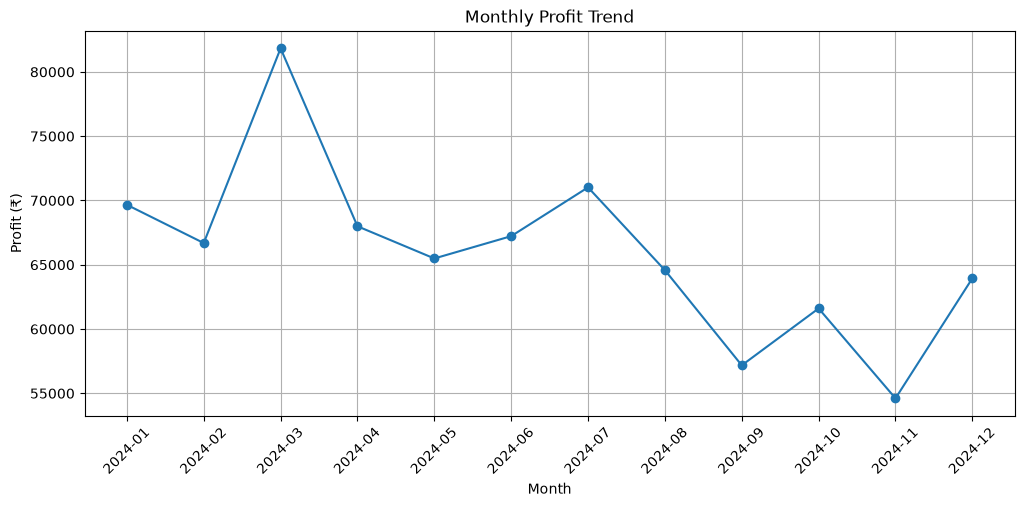

In [58]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly["Month"],
    monthly["Profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit (₹)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [59]:
category_analysis = df.groupby("category").agg(
    Orders=("order_id", "nunique"),
    Revenue=("Revenue", "sum"),
    Discount=("Discount_Amount", "sum"),
    Cost=("Total_Cost", "sum"),
    Profit=("Profit", "sum")
).reset_index()

category_analysis["Profit_Margin"] = (
    category_analysis["Profit"] /
    (category_analysis["Revenue"] - category_analysis["Discount"]) * 100
)

category_analysis = category_analysis.sort_values(
    "Profit_Margin",
    ascending=False
)

category_analysis.round(2)

,category,Orders,Revenue,Discount,Cost,Profit,Profit_Margin
2,Food,910,1151974.40,86775.06,854229,210970.34,19.81
0,Electronics,847,1068090.46,80584.78,793430,194075.68,19.65
3,Grocery,875,1097414.68,83678.94,817103,196632.74,19.40
1,Fashion,868,1080468.57,83083.59,807245,190139.98,19.06


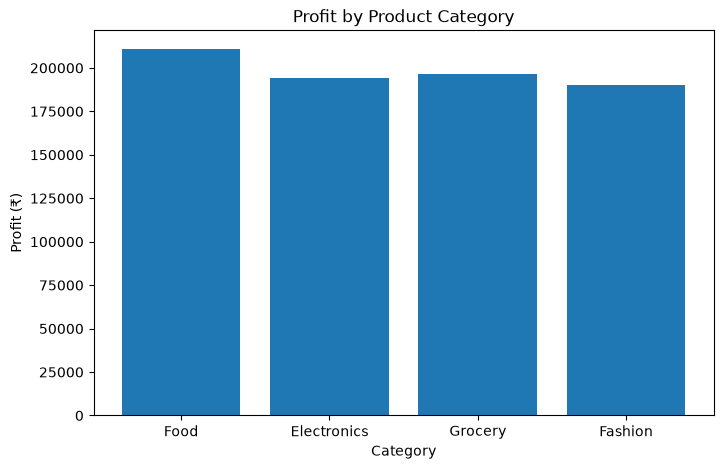

In [60]:
plt.figure(figsize=(8,5))

plt.bar(
    category_analysis["category"],
    category_analysis["Profit"]
)

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit (₹)")

plt.show()

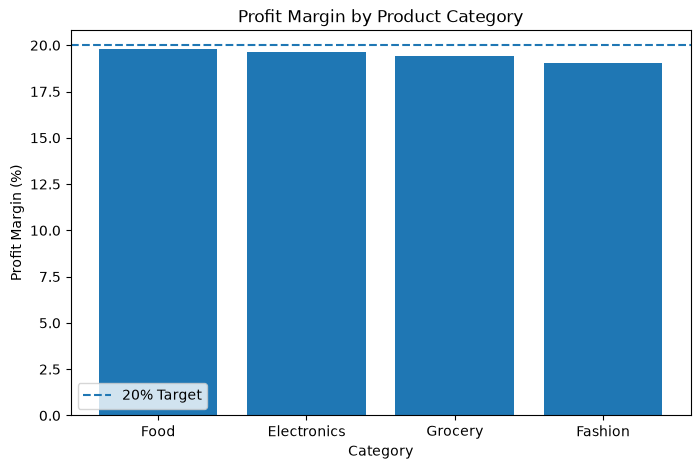

In [61]:
plt.figure(figsize=(8,5))

plt.bar(
    category_analysis["category"],
    category_analysis["Profit_Margin"]
)

plt.axhline(
    y=20,
    linestyle="--",
    label="20% Target"
)

plt.title("Profit Margin by Product Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")
plt.legend()

plt.show()

In [62]:
city_analysis = df.groupby("city_order").agg(
    Orders=("order_id", "nunique"),
    Revenue=("Revenue", "sum"),
    Discount=("Discount_Amount", "sum"),
    Profit=("Profit", "sum")
).reset_index()

city_analysis["Profit_Margin"] = (
    city_analysis["Profit"] /
    (city_analysis["Revenue"] - city_analysis["Discount"]) * 100
)

city_analysis = city_analysis.sort_values(
    "Profit",
    ascending=False
)

city_analysis.round(2)

,city_order,Orders,Revenue,Discount,Profit,Profit_Margin
1,Chennai,647,847827.15,62763.41,156555.74,19.94
3,Hyderabad,636,798365.37,61915.74,143513.63,19.49
4,Mumbai,607,748079.48,55192.92,137716.56,19.88
0,Bangalore,558,707770.90,53602.80,128392.10,19.63
2,Delhi,519,650655.36,48365.51,115606.85,19.19
5,Pune,533,645249.85,52281.99,110033.86,18.56


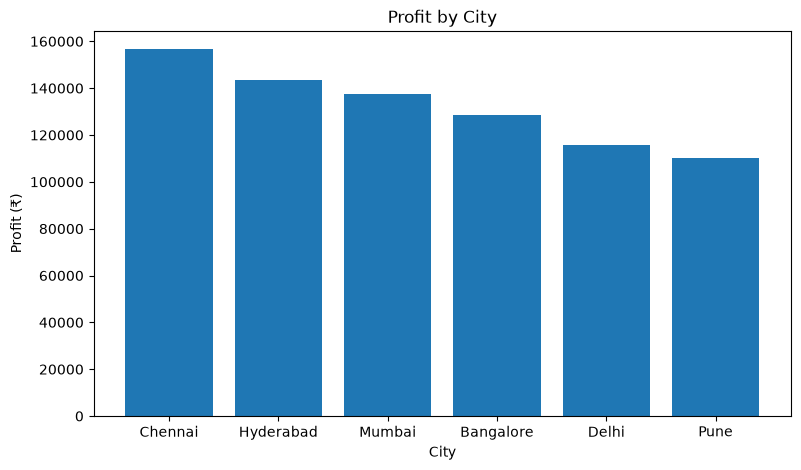

In [63]:
plt.figure(figsize=(9,5))

plt.bar(
    city_analysis["city_order"],
    city_analysis["Profit"]
)

plt.title("Profit by City")
plt.xlabel("City")
plt.ylabel("Profit (₹)")

plt.show()

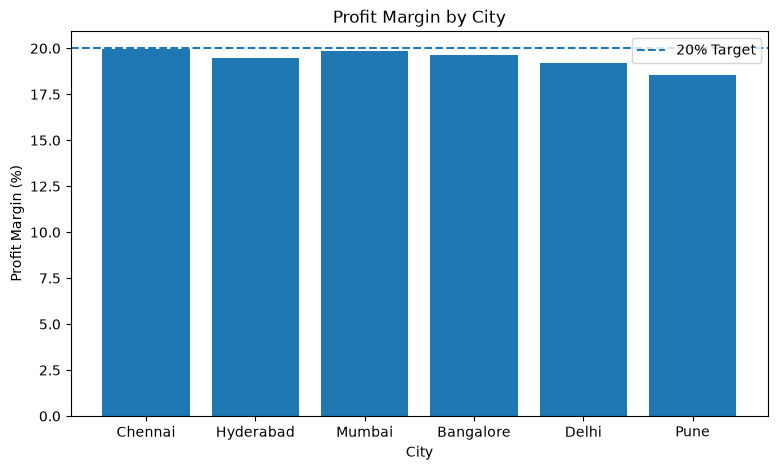

In [64]:
plt.figure(figsize=(9,5))

plt.bar(
    city_analysis["city_order"],
    city_analysis["Profit_Margin"]
)

plt.axhline(
    y=20,
    linestyle="--",
    label="20% Target"
)

plt.title("Profit Margin by City")
plt.xlabel("City")
plt.ylabel("Profit Margin (%)")
plt.legend()

plt.show()

In [65]:
membership_analysis = df.groupby("membership").agg(
    Customers=("customer_id", "nunique"),
    Orders=("order_id", "nunique"),
    Revenue=("Revenue", "sum"),
    Discount=("Discount_Amount", "sum"),
    Profit=("Profit", "sum")
).reset_index()

membership_analysis["Profit_Margin"] = (
    membership_analysis["Profit"] /
    (membership_analysis["Revenue"] - membership_analysis["Discount"])
) * 100

membership_analysis = membership_analysis.sort_values(
    "Profit",
    ascending=False
)

membership_analysis.round(2)

,membership,Customers,Orders,Revenue,Discount,Profit,Profit_Margin
1,Normal,387,1688,2112215.47,160773.17,378994.30,19.42
2,Silver,248,1119,1420950.59,112388.23,252521.36,19.30
0,Gold,150,693,864782.05,60960.97,160303.08,19.94


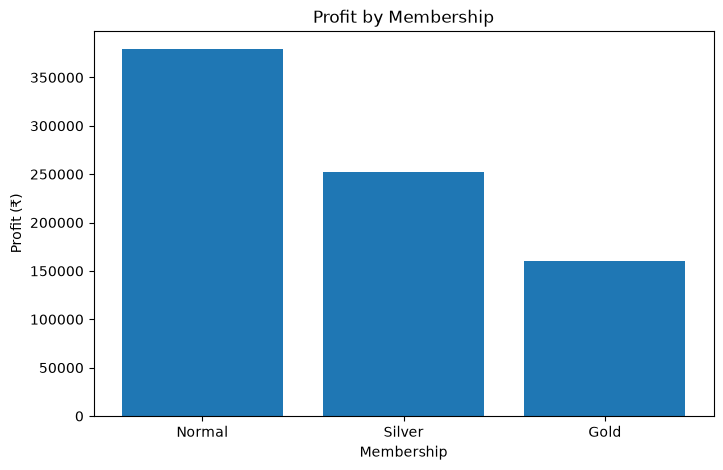

In [66]:
plt.figure(figsize=(8,5))

plt.bar(
    membership_analysis["membership"],
    membership_analysis["Profit"]
)

plt.title("Profit by Membership")
plt.xlabel("Membership")
plt.ylabel("Profit (₹)")

plt.show()

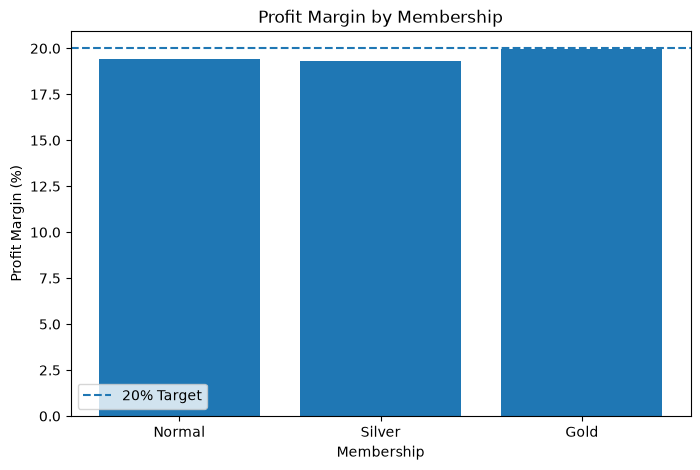

In [67]:
plt.figure(figsize=(8,5))

plt.bar(
    membership_analysis["membership"],
    membership_analysis["Profit_Margin"]
)

plt.axhline(
    y=20,
    linestyle="--",
    label="20% Target"
)

plt.title("Profit Margin by Membership")
plt.xlabel("Membership")
plt.ylabel("Profit Margin (%)")
plt.legend()

plt.show()

In [69]:
df["order_date"] = pd.to_datetime(df["order_date"])

df = df.sort_values(["customer_id", "order_date"])

df["Customer_Type"] = (
    df.groupby("customer_id")
      .cumcount()
      .apply(lambda x: "New" if x == 0 else "Repeat")
)

df[["customer_id", "order_id", "order_date", "Customer_Type"]].head(10)

,customer_id,order_id,order_date,Customer_Type
2036,10001,92037,2024-01-02,New
1167,10001,91168,2024-03-29,Repeat
1961,10001,91962,2024-08-22,Repeat
1347,10001,91348,2024-11-01,Repeat
1084,10002,91085,2024-02-03,New
185,10002,90186,2024-03-10,Repeat
3486,10002,93487,2024-05-13,Repeat
1114,10002,91115,2024-05-19,Repeat
955,10002,90956,2024-08-19,Repeat
1835,10002,91836,2024-09-21,Repeat


In [70]:
df["Customer_Type"].value_counts()

Customer_Type
Repeat    2715
New        785
Name: count, dtype: int64

In [71]:
customer_type_analysis = df.groupby("Customer_Type").agg(
    Customers=("customer_id", "nunique"),
    Orders=("order_id", "nunique"),
    Revenue=("Revenue", "sum"),
    Discount=("Discount_Amount", "sum"),
    Profit=("Profit", "sum")
).reset_index()

customer_type_analysis["Profit_Margin"] = (
    customer_type_analysis["Profit"] /
    (customer_type_analysis["Revenue"] - customer_type_analysis["Discount"])
) * 100

customer_type_analysis = customer_type_analysis.sort_values(
    "Profit",
    ascending=False
)

customer_type_analysis.round(2)

,Customer_Type,Customers,Orders,Revenue,Discount,Profit,Profit_Margin
1,Repeat,743,2715,3383511.89,256142.44,603921.45,19.31
0,New,785,785,1014436.22,77979.94,187897.28,20.06


In [72]:
customer_type_analysis.round(2)

,Customer_Type,Customers,Orders,Revenue,Discount,Profit,Profit_Margin
1,Repeat,743,2715,3383511.89,256142.44,603921.45,19.31
0,New,785,785,1014436.22,77979.94,187897.28,20.06


In [73]:
age_analysis = df.groupby("Age_Group").agg(
    Customers=("customer_id", "nunique"),
    Orders=("order_id", "nunique"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
).reset_index()

age_analysis["Average_Order_Value"] = (
    age_analysis["Revenue"] / age_analysis["Orders"]
)

age_analysis["Profit_Margin"] = (
    age_analysis["Profit"] /
    (df.groupby("Age_Group")["Net_Revenue"].sum().values)
) * 100

age_analysis.round(2)

C:\Users\admin.MYLAB1\AppData\Local\Temp\ipykernel_10388\163537504.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_analysis = df.groupby("Age_Group").agg(
C:\Users\admin.MYLAB1\AppData\Local\Temp\ipykernel_10388\163537504.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby("Age_Group")["Net_Revenue"].sum().values)


,Age_Group,Customers,Orders,Revenue,Profit,Average_Order_Value,Profit_Margin
0,Young Adult,148,705,875677.27,157934.99,1242.10,19.48
1,Adult,253,1130,1434371.39,264447.94,1269.36,19.93
2,Senior,384,1665,2087899.45,369435.80,1253.99,19.18


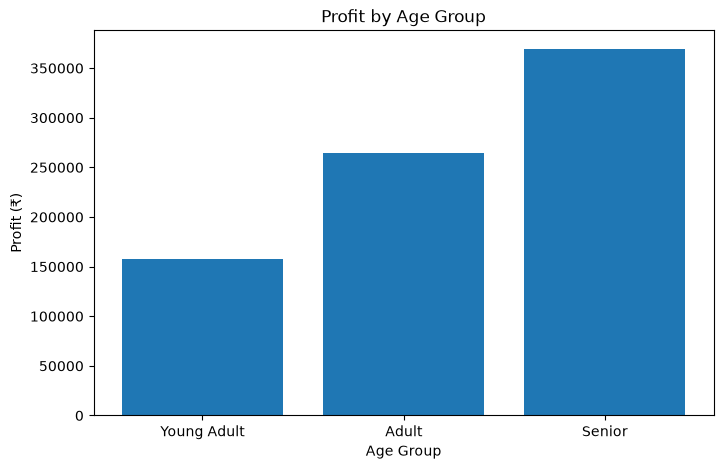

In [74]:
plt.figure(figsize=(8,5))

plt.bar(
    age_analysis["Age_Group"],
    age_analysis["Profit"]
)

plt.title("Profit by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Profit (₹)")

plt.show()

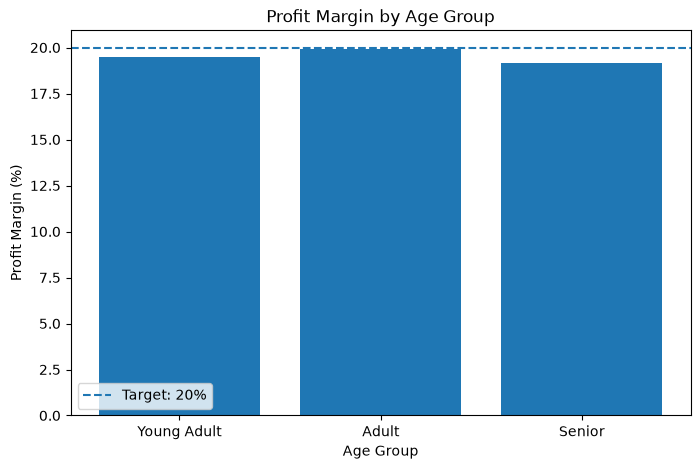

In [76]:
plt.figure(figsize=(8,5))

plt.bar(
    age_analysis["Age_Group"],
    age_analysis["Profit_Margin"]
)

plt.axhline(
    y=20,
    linestyle="--",
    label="Target: 20%"
)

plt.title("Profit Margin by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Profit Margin (%)")

plt.legend()

plt.show()

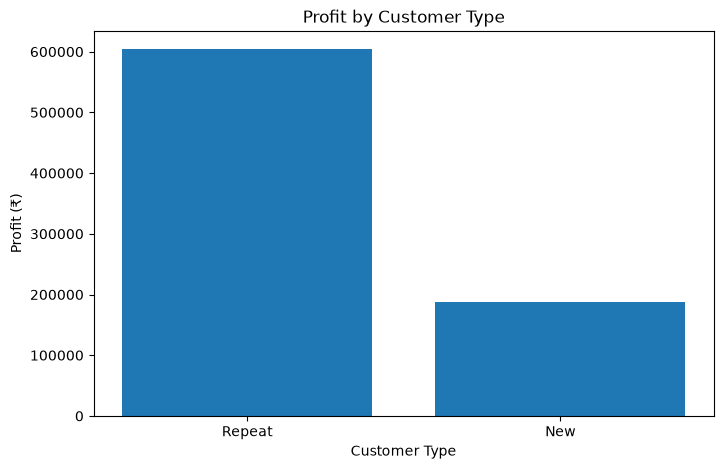

In [77]:
plt.figure(figsize=(8,5))

plt.bar(
    customer_type_analysis["Customer_Type"],
    customer_type_analysis["Profit"]
)

plt.title("Profit by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Profit (₹)")

plt.show()

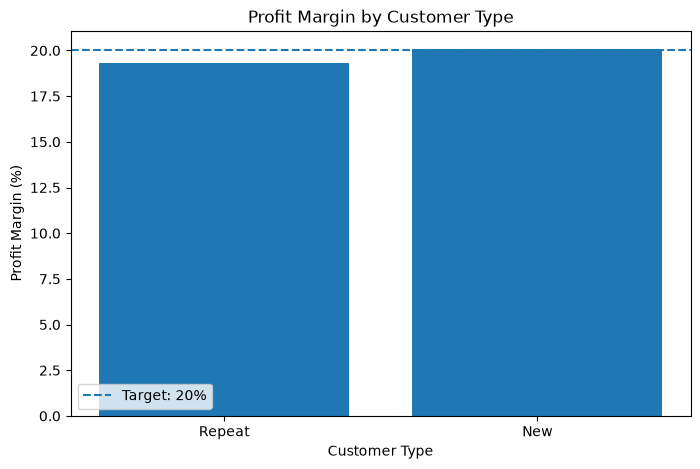

In [79]:
plt.figure(figsize=(8,5))

plt.bar(
    customer_type_analysis["Customer_Type"],
    customer_type_analysis["Profit_Margin"]
)

plt.axhline(
    y=20,
    linestyle="--",
    label="Target: 20%"
)

plt.title("Profit Margin by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Profit Margin (%)")

plt.legend()

plt.show()

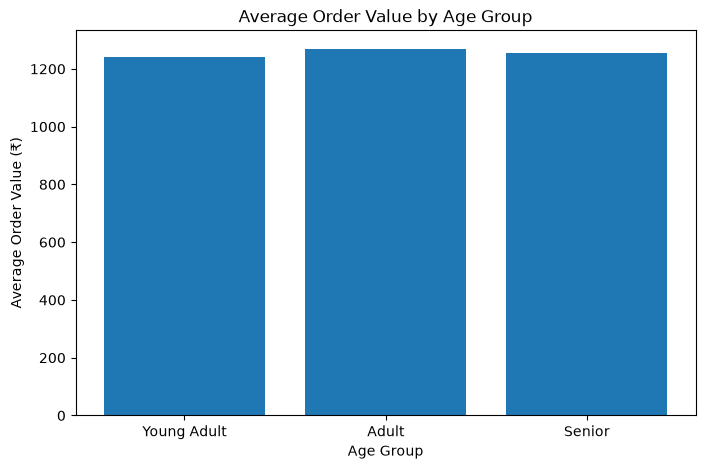

In [80]:
plt.figure(figsize=(8,5))

plt.bar(
    age_analysis["Age_Group"],
    age_analysis["Average_Order_Value"]
)

plt.title("Average Order Value by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Order Value (₹)")

plt.show()

In [81]:
discount_analysis = df.groupby("discount").agg(
    Orders=("order_id", "nunique"),
    Revenue=("Revenue", "sum"),
    Discount_Amount=("Discount_Amount", "sum"),
    Profit=("Profit", "sum"),
    Net_Revenue=("Net_Revenue", "sum")
).reset_index()

discount_analysis["Profit_Margin"] = (
    discount_analysis["Profit"] /
    discount_analysis["Net_Revenue"]
) * 100

discount_analysis.round(2)

,discount,Orders,Revenue,Discount_Amount,Profit,Net_Revenue,Profit_Margin
0,0,1051,1303662.35,0.00,334322.35,1303662.35,25.64
1,5,868,1108842.49,55442.12,229297.37,1053400.37,21.77
2,10,686,828809.04,82880.90,131045.14,745928.14,17.57
3,15,556,710549.98,106582.50,71581.48,603967.48,11.85
4,20,339,446084.25,89216.85,25572.40,356867.40,7.17


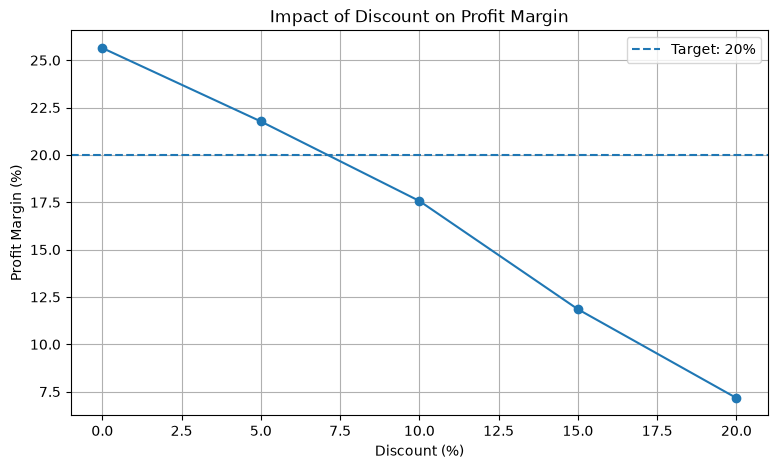

In [82]:
plt.figure(figsize=(9,5))

plt.plot(
    discount_analysis["discount"],
    discount_analysis["Profit_Margin"],
    marker="o"
)

plt.axhline(
    y=20,
    linestyle="--",
    label="Target: 20%"
)

plt.title("Impact of Discount on Profit Margin")
plt.xlabel("Discount (%)")
plt.ylabel("Profit Margin (%)")

plt.legend()
plt.grid(True)

plt.show()

In [83]:
# Simulate reducing discount by 5 percentage points
df["Reduced_Discount"] = (df["discount"] - 5).clip(lower=0)

# Calculate the new discount amount
df["Reduced_Discount_Amount"] = (
    df["Revenue"] * df["Reduced_Discount"] / 100
)

# Calculate new net revenue
df["Reduced_Net_Revenue"] = (
    df["Revenue"] - df["Reduced_Discount_Amount"]
)

# Calculate new profit
df["Reduced_Profit"] = (
    df["Reduced_Net_Revenue"] - df["Total_Cost"]
)

# Calculate new profit margin
df["Reduced_Profit_Margin"] = (
    df["Reduced_Profit"] / df["Reduced_Net_Revenue"]
) * 100

print("Current Profit: ₹", round(df["Profit"].sum(), 2))
print("Simulated Profit: ₹", round(df["Reduced_Profit"].sum(), 2))

print(
    "Potential Additional Profit: ₹",
    round(df["Reduced_Profit"].sum() - df["Profit"].sum(), 2)
)

print(
    "Current Profit Margin:",
    round(df["Profit"].sum() / df["Net_Revenue"].sum() * 100, 2),
    "%"
)

print(
    "Simulated Profit Margin:",
    round(
        df["Reduced_Profit"].sum() /
        df["Reduced_Net_Revenue"].sum() * 100,
        2
    ),
    "%"
)

Current Profit: ₹ 791818.73
Simulated Profit: ₹ 946533.02
Potential Additional Profit: ₹ 154714.29
Current Profit Margin: 19.48 %
Simulated Profit Margin: 22.44 %


In [84]:
product_analysis = df.groupby(
    ["product_id", "product_name"]
).agg(
    Orders=("order_id", "nunique"),
    Quantity=("quantity", "sum"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    Net_Revenue=("Net_Revenue", "sum")
).reset_index()

product_analysis["Profit_Margin"] = (
    product_analysis["Profit"] /
    product_analysis["Net_Revenue"]
) * 100

product_analysis = product_analysis.sort_values(
    "Profit",
    ascending=True
)

product_analysis.head(10).round(2)

,product_id,product_name,Orders,Quantity,Revenue,Profit,Net_Revenue,Profit_Margin
152,5153,Product_152,9,23,2204.42,427.51,2037.51,20.98
145,5146,Product_145,16,39,2714.41,452.62,2480.62,18.25
187,5188,Product_187,16,41,4571.97,533.06,4141.06,12.87
184,5185,Product_184,19,53,3855.01,570.55,3485.55,16.37
70,5071,Product_70,12,31,3736.73,620.96,3410.96,18.20
162,5163,Product_162,9,24,5652.50,660.67,5196.67,12.71
2,5003,Product_2,11,32,3006.95,672.94,2880.94,23.36
74,5075,Product_74,17,35,4098.17,719.66,3799.66,18.94
41,5042,Product_41,20,58,4356.93,786.77,4034.77,19.50
36,5037,Product_36,13,36,3670.92,804.48,3468.48,23.19


In [85]:
low_margin_products = product_analysis.sort_values(
    "Profit_Margin",
    ascending=True
).head(10)

low_margin_products.round(2)

,product_id,product_name,Orders,Quantity,Revenue,Profit,Net_Revenue,Profit_Margin
166,5167,Product_166,11,28,20531.14,2098.55,18450.55,11.37
179,5180,Product_179,19,45,23677.95,2583.00,21078.00,12.25
162,5163,Product_162,9,24,5652.50,660.67,5196.67,12.71
4,5005,Product_4,18,49,12481.72,1409.07,11062.07,12.74
187,5188,Product_187,16,41,4571.97,533.06,4141.06,12.87
119,5120,Product_119,26,63,18938.05,2275.07,17143.07,13.27
106,5107,Product_106,13,32,17831.51,2155.37,16107.37,13.38
71,5072,Product_71,16,35,9416.89,1199.63,8864.63,13.53
169,5170,Product_169,12,33,15924.52,1952.80,14096.80,13.85
6,5007,Product_6,23,56,33460.61,4099.00,29411.00,13.94


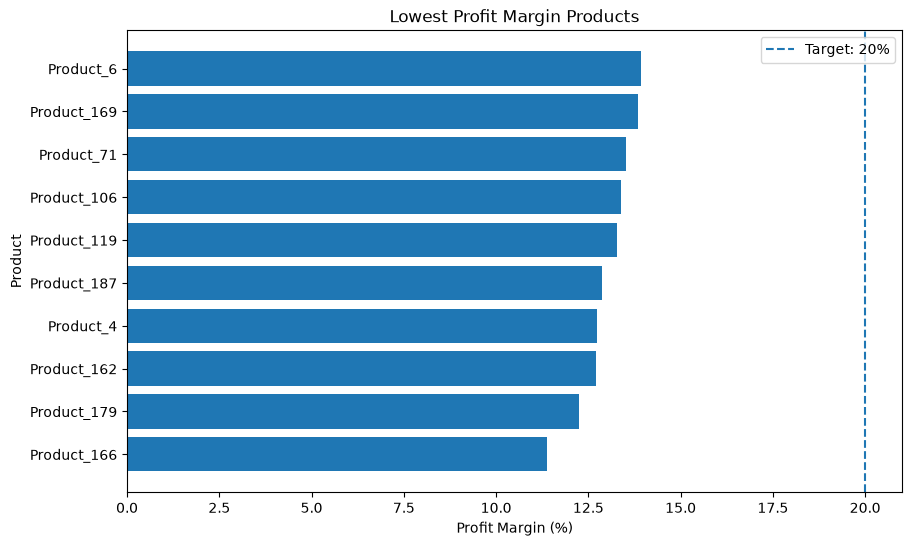

In [86]:
plt.figure(figsize=(10,6))

plt.barh(
    low_margin_products["product_name"],
    low_margin_products["Profit_Margin"]
)

plt.axvline(
    x=20,
    linestyle="--",
    label="Target: 20%"
)

plt.title("Lowest Profit Margin Products")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Product")

plt.legend()
plt.show()

In [87]:
payment_analysis = df.groupby("payment_type").agg(
    Customers=("customer_id", "nunique"),
    Orders=("order_id", "count"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
).reset_index()

payment_analysis["Avg_Order_Value"] = (
    payment_analysis["Revenue"] / payment_analysis["Orders"]
)

payment_analysis["Profit_Margin"] = (
    payment_analysis["Profit"] / payment_analysis["Revenue"] * 100
)

payment_analysis.round(2)

,payment_type,Customers,Orders,Revenue,Profit,Avg_Order_Value,Profit_Margin
0,COD,518,832,1066943.26,199952.77,1282.38,18.74
1,Card,515,867,1086858.64,192306.02,1253.59,17.69
2,UPI,524,894,1115982.28,199656.09,1248.30,17.89
3,Wallet,542,907,1128163.93,199903.85,1243.84,17.72


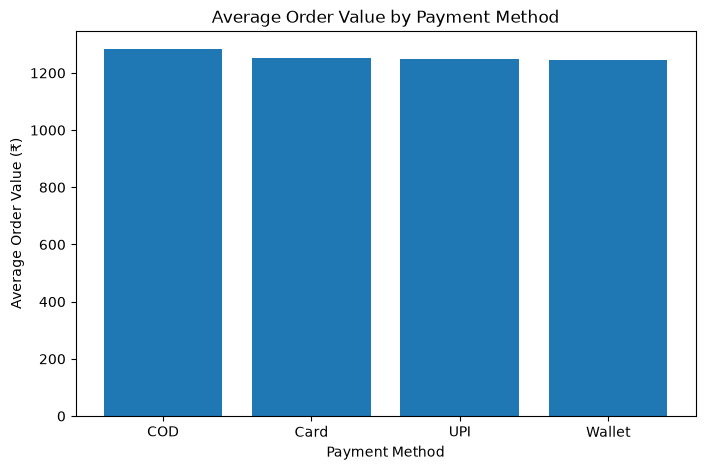

In [88]:
plt.figure(figsize=(8,5))

plt.bar(
    payment_analysis["payment_type"],
    payment_analysis["Avg_Order_Value"]
)

plt.title("Average Order Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Order Value (₹)")

plt.show()

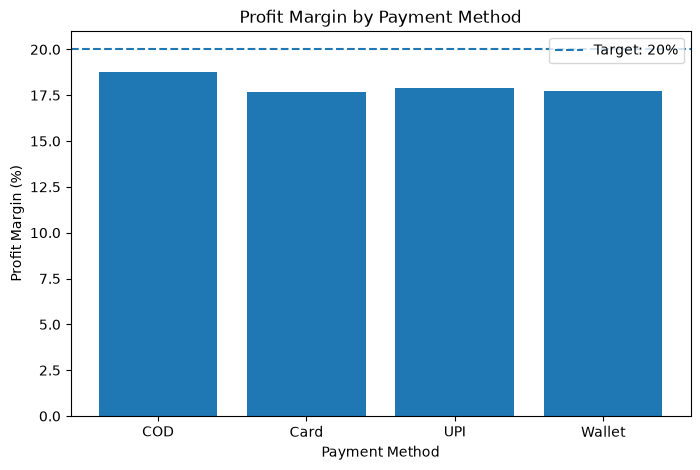

In [89]:
plt.figure(figsize=(8,5))

plt.bar(
    payment_analysis["payment_type"],
    payment_analysis["Profit_Margin"]
)

plt.axhline(
    y=20,
    linestyle="--",
    label="Target: 20%"
)

plt.title("Profit Margin by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Profit Margin (%)")

plt.legend()

plt.show()

In [90]:
print(df.columns.tolist())

['order_id', 'order_date', 'customer_id', 'city_order', 'product_id', 'category', 'quantity', 'selling_price', 'discount', 'payment_type', 'delivery_time', 'age', 'gender', 'city_customer', 'signup_date', 'membership', 'product_name', 'cost_price', 'brand', 'rating', 'supplier', 'Revenue', 'Discount_Amount', 'Net_Revenue', 'Total_Cost', 'Profit', 'Profit_Margin', 'Age_Group', 'Customer_Tenure_Days', 'Tenure_Group', 'Delivery_Category', 'Customer_Type', 'Reduced_Discount', 'Reduced_Discount_Amount', 'Reduced_Net_Revenue', 'Reduced_Profit', 'Reduced_Profit_Margin']


In [91]:
# Create required Delivery_Status column

df["Delivery_Status"] = np.where(
    df["delivery_time"] > 60,
    "Late",
    "On-Time"
)

print(df["Delivery_Status"].value_counts())

Delivery_Status
Late       2064
On-Time    1436
Name: count, dtype: int64


In [92]:
delivery_customer_analysis = df.groupby(
    ["Delivery_Status", "Customer_Type"]
).agg(
    Orders=("order_id", "count"),
    Customers=("customer_id", "nunique"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
).reset_index()

delivery_customer_analysis["Profit_Margin"] = (
    delivery_customer_analysis["Profit"] /
    df.groupby(["Delivery_Status", "Customer_Type"])["Net_Revenue"].sum().values
) * 100

delivery_customer_analysis.round(2)

,Delivery_Status,Customer_Type,Orders,Customers,Revenue,Profit,Profit_Margin
0,Late,New,464,464,588984.44,110552.20,20.25
1,Late,Repeat,1600,662,1993481.69,362846.79,19.63
2,On-Time,New,321,321,425451.78,77345.08,19.81
3,On-Time,Repeat,1115,584,1390030.20,241074.66,18.85


In [93]:
delivery_profit_analysis = df.groupby("Delivery_Status").agg(
    Orders=("order_id", "count"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    Net_Revenue=("Net_Revenue", "sum"),
    Avg_Delivery_Time=("delivery_time", "mean")
).reset_index()

delivery_profit_analysis["Profit_Margin"] = (
    delivery_profit_analysis["Profit"] /
    delivery_profit_analysis["Net_Revenue"]
) * 100

delivery_profit_analysis.round(2)

,Delivery_Status,Orders,Revenue,Profit,Net_Revenue,Avg_Delivery_Time,Profit_Margin
0,Late,2064,2582466.13,473398.99,2394760.99,89.44,19.77
1,On-Time,1436,1815481.98,318419.74,1669064.74,39.92,19.08


In [94]:
df["Discount_Bucket"] = pd.cut(
    df["discount"],
    bins=[-1, 0, 10, 20, 100],
    labels=["0%", "1-10%", "11-20%", "20%+"]
)

discount_bucket_analysis = df.groupby(
    "Discount_Bucket",
    observed=False
).agg(
    Orders=("order_id", "count"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    Net_Revenue=("Net_Revenue", "sum")
).reset_index()

discount_bucket_analysis["Profit_Margin"] = (
    discount_bucket_analysis["Profit"] /
    discount_bucket_analysis["Net_Revenue"]
) * 100

discount_bucket_analysis.round(2)

,Discount_Bucket,Orders,Revenue,Profit,Net_Revenue,Profit_Margin
0,0%,1051,1303662.35,334322.35,1303662.35,25.64
1,1-10%,1554,1937651.53,360342.50,1799328.50,20.03
2,11-20%,895,1156634.23,97153.88,960834.88,10.11
3,20%+,0,0.00,0.00,0.00,NaN


In [95]:
customer_segment_analysis = df.groupby(
    ["membership", "Customer_Type"]
).agg(
    Customers=("customer_id", "nunique"),
    Orders=("order_id", "count"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum"),
    Net_Revenue=("Net_Revenue", "sum")
).reset_index()

customer_segment_analysis["Profit_Margin"] = (
    customer_segment_analysis["Profit"] /
    customer_segment_analysis["Net_Revenue"]
) * 100

customer_segment_analysis = customer_segment_analysis.sort_values(
    "Profit",
    ascending=False
)

customer_segment_analysis.round(2)

,membership,Customer_Type,Customers,Orders,Revenue,Profit,Net_Revenue,Profit_Margin
3,Normal,Repeat,364,1301,1617977.33,288097.61,1495343.61,19.27
5,Silver,Repeat,238,871,1085199.55,192078.69,1001211.69,19.18
1,Gold,Repeat,141,543,680335.01,123745.15,630814.15,19.62
2,Normal,New,387,387,494238.14,90896.69,456098.69,19.93
4,Silver,New,248,248,335751.04,60442.67,307350.67,19.67
0,Gold,New,150,150,184447.04,36557.92,173006.92,21.13


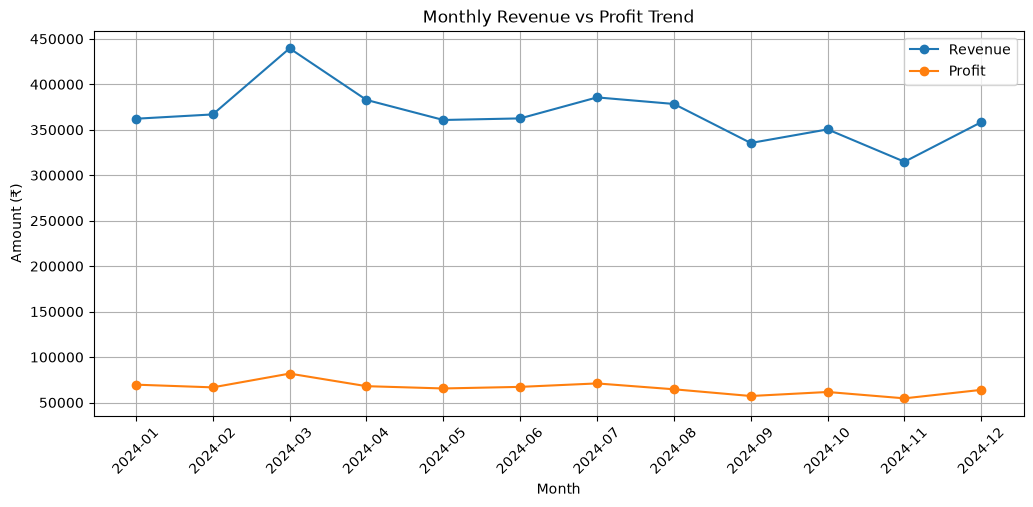

In [96]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly["Month"],
    monthly["Revenue"],
    marker="o",
    label="Revenue"
)

plt.plot(
    monthly["Month"],
    monthly["Profit"],
    marker="o",
    label="Profit"
)

plt.title("Monthly Revenue vs Profit Trend")
plt.xlabel("Month")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [97]:
rating_analysis = df.groupby("rating").agg(
    Products=("product_id", "nunique"),
    Orders=("order_id", "nunique"),
    Quantity=("quantity", "sum"),
    Revenue=("Revenue", "sum")
).reset_index()

rating_analysis = rating_analysis.sort_values("rating")

rating_analysis.round(2)

,rating,Products,Orders,Quantity,Revenue
0,2.5,4,70,172,73579.10
1,2.6,10,175,445,237926.36
2,2.7,7,124,309,138715.30
3,2.8,1,14,35,14689.54
4,2.9,8,135,357,189324.34
5,3.0,11,190,506,198601.29
6,3.1,7,108,263,134696.61
7,3.2,8,129,312,160784.19
8,3.3,7,119,313,153564.41
9,3.4,5,82,212,125137.25


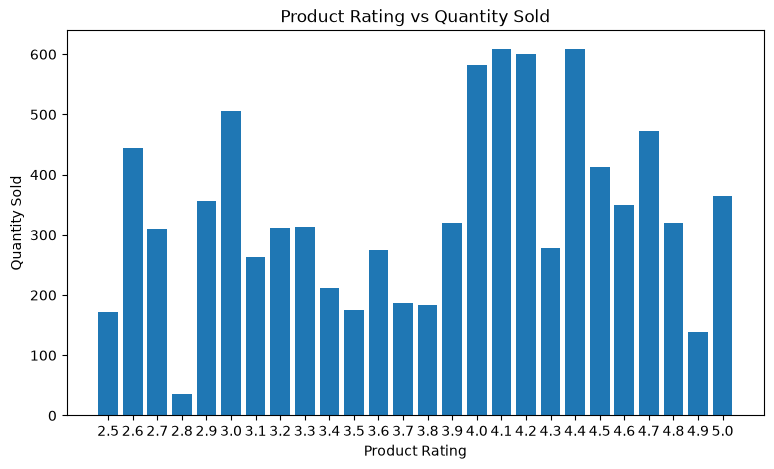

In [99]:
plt.figure(figsize=(9,5))

plt.bar(
    rating_analysis["rating"].astype(str),
    rating_analysis["Quantity"]
)

plt.title("Product Rating vs Quantity Sold")
plt.xlabel("Product Rating")
plt.ylabel("Quantity Sold")

plt.show()

In [100]:
customer_value = df.groupby("customer_id").agg(
    Orders=("order_id", "nunique"),
    Revenue=("Revenue", "sum"),
    Profit=("Profit", "sum")
).reset_index()

customer_value["Profit_Margin"] = (
    customer_value["Profit"] /
    customer_value["Revenue"] * 100
)

customer_value = customer_value.sort_values(
    "Profit",
    ascending=False
)

customer_value.head(10).round(2)

,customer_id,Orders,Revenue,Profit,Profit_Margin
69,10070,8,15702.78,3825.03,24.36
361,10369,6,13068.89,3484.19,26.66
687,10703,9,13839.96,3394.06,24.52
721,10737,12,17717.96,3327.66,18.78
260,10267,7,11866.36,3298.89,27.80
342,10350,10,13671.90,3185.59,23.30
24,10025,9,12301.97,3134.60,25.48
266,10274,6,11172.71,3119.75,27.92
745,10761,5,12678.21,3095.63,24.42
134,10137,5,11017.78,3086.69,28.02


## The most valuable customers were identified based on total profit generated. Customer 10070 generated the highest profit of ₹3,825.03 from 8 orders. Customer 10369 and Customer 10703 were the next highest contributors. The results show that customer value depends on both order frequency and profitability, rather than revenue alone.